In [1]:
from pathlib import Path
import pandas as pd

In [2]:
weather=pd.read_csv('../data/raw/london_10years.csv')
demand=pd.read_csv('../data/raw/electricity_demand.csv')

In [3]:
weather['time']=pd.to_datetime(weather['time'])
demand['time']=pd.to_datetime(demand['time'])
merge=pd.merge(weather,demand,on='time',how='inner')

output_path=Path('../data/interim/merged_data.csv')
merge.to_csv(output_path,index=False)

In [4]:
corr_df=merge.select_dtypes(include='number').corr()['ENGLAND_WALES_DEMAND'].sort_values(key=lambda s:s.abs(),ascending=False)
print(corr_df)

ENGLAND_WALES_DEMAND         1.000000
ND                           0.998015
TSD                          0.984994
PUMP_STORAGE_PUMPING        -0.419144
BRITNED_FLOW                 0.280859
temperature_2m              -0.240950
EMBEDDED_WIND_CAPACITY      -0.234351
EMBEDDED_SOLAR_CAPACITY     -0.233961
NON_BM_STOR                  0.157314
wind_speed_10m               0.142363
EMBEDDED_SOLAR_GENERATION   -0.112297
IFA_FLOW                     0.105030
SCOTTISH_TRANSFER            0.096996
MOYLE_FLOW                  -0.091081
EAST_WEST_FLOW              -0.082551
GREENLINK_FLOW               0.073293
NEMO_FLOW                    0.068083
ELECLINK_FLOW               -0.057382
EMBEDDED_WIND_GENERATION     0.057087
relative_humidity_2m        -0.042126
VIKING_FLOW                  0.036624
IFA2_FLOW                   -0.030885
NSL_FLOW                     0.020496
Name: ENGLAND_WALES_DEMAND, dtype: float64


except the temp wind and humidity the rest all put in supply to analyse

In [5]:
import matplotlib.pyplot as plt

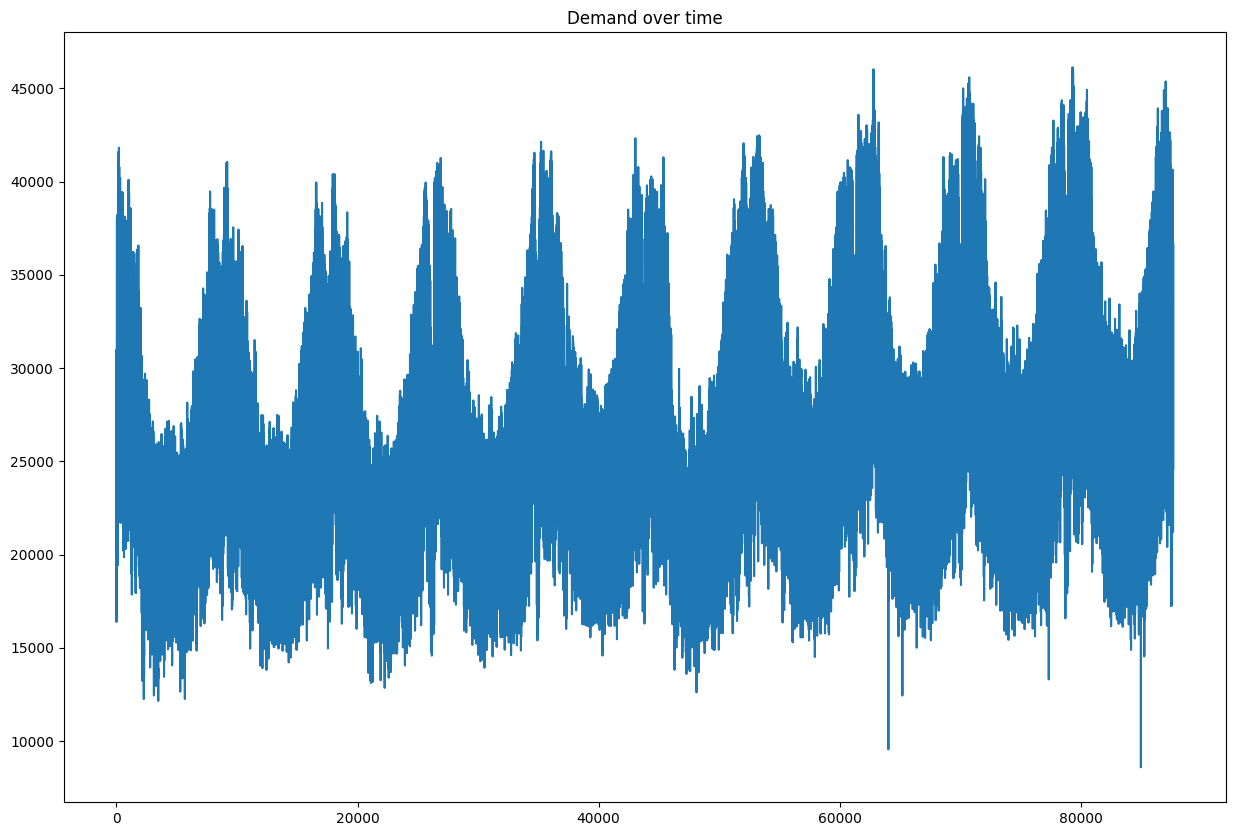

In [6]:
plt.figure(figsize=(15,10))
plt.plot(merge['ENGLAND_WALES_DEMAND'].values)
plt.title('Demand over time')
plt.show()

seasonal fluctuating

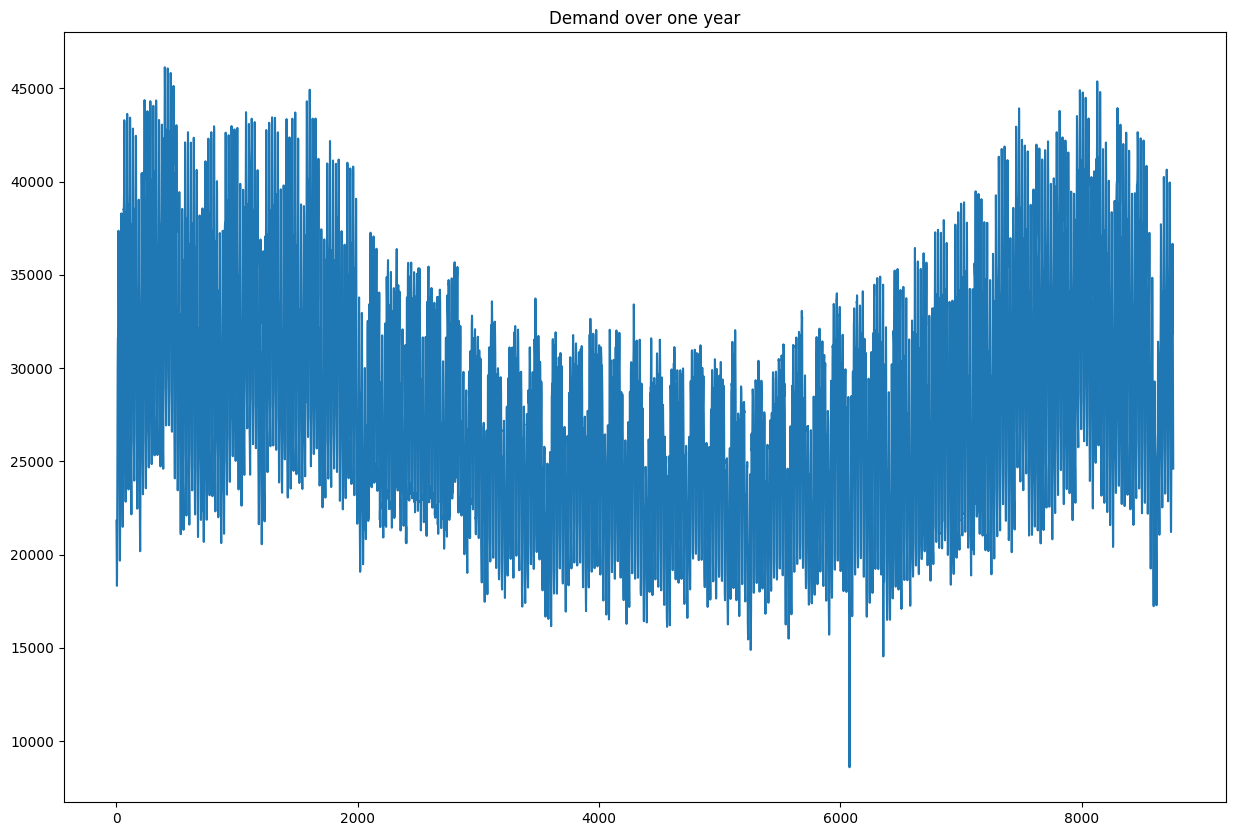

In [7]:
plt.figure(figsize=(15,10))
data_2025=merge[merge['time'].dt.year==2025]
plt.plot(data_2025['ENGLAND_WALES_DEMAND'].values)
plt.title('Demand over one year')
plt.show()


Jan Feb Nov and Dec has higher average temperature

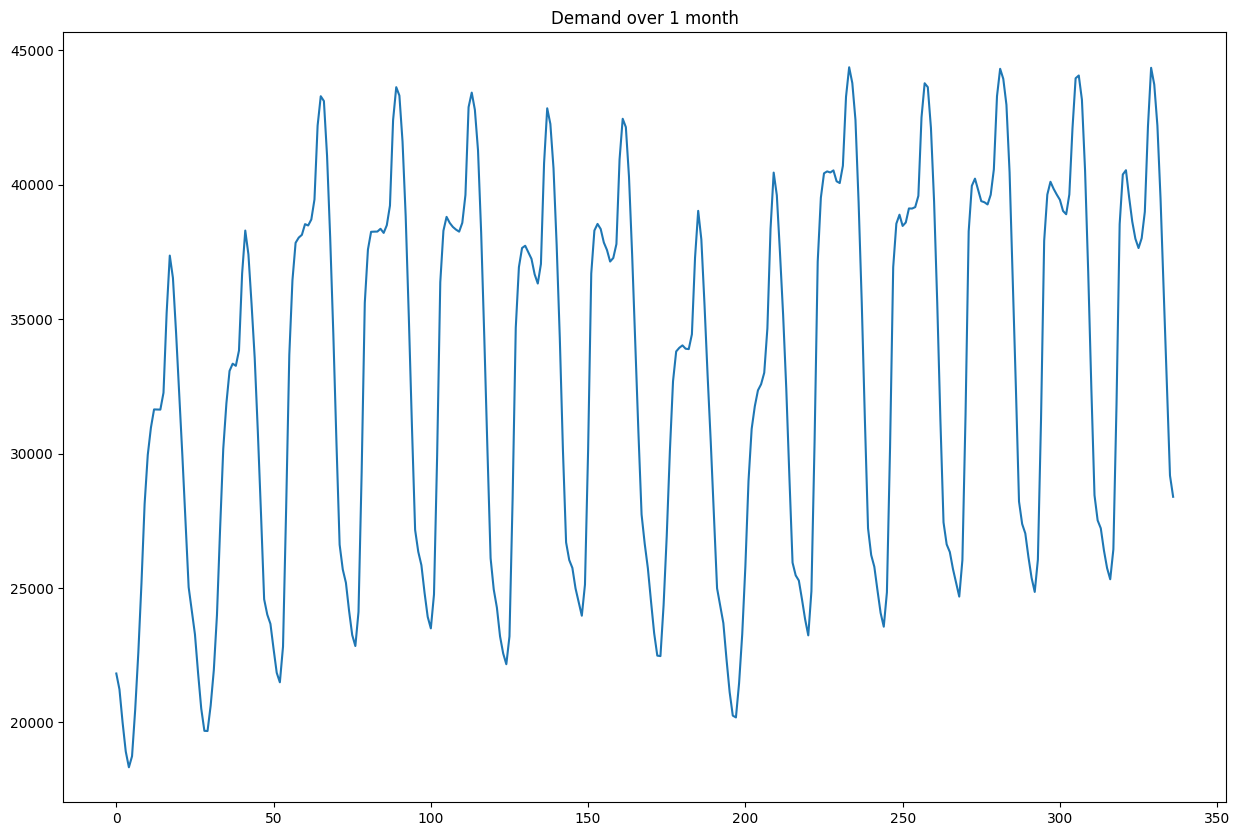

In [8]:
plt.figure(figsize=(15,10))
data_half_m=merge[(merge['time']>='2025-01-01')&(merge['time']<='2025-01-15')]
plt.plot(data_half_m['ENGLAND_WALES_DEMAND'].values)
plt.title('Demand over 1 month')
plt.show()

daily fluctating

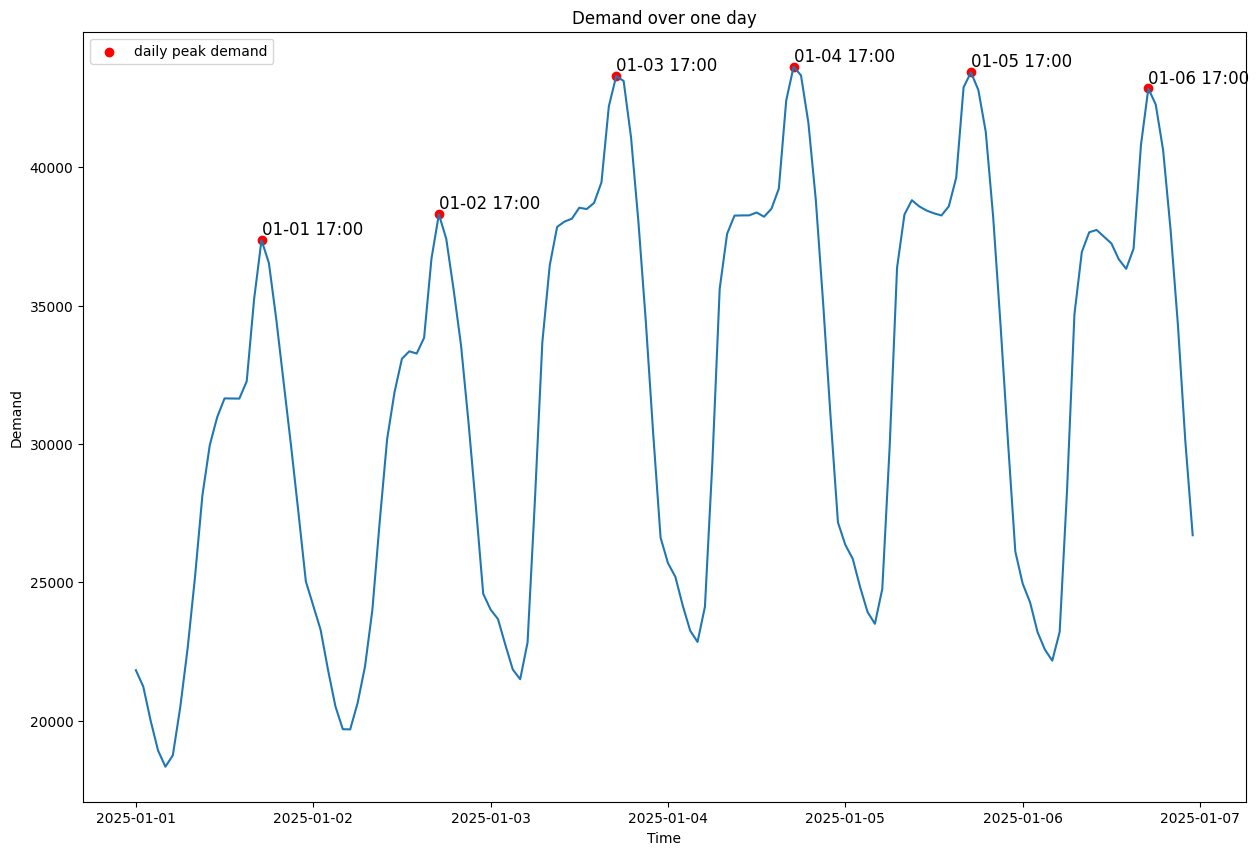

In [9]:
plt.figure(figsize=(15,10))
data_day=merge[(merge['time']>='2025-01-01 00:00:00')&(merge['time']<='2025-01-06 23:00:00')]
plt.plot(data_day['time'],data_day['ENGLAND_WALES_DEMAND'].values)
plt.title('Demand over one day')
data_day['date']=data_day['time'].dt.date
idx=data_day.groupby('date')['ENGLAND_WALES_DEMAND'].idxmax()
daily_peak=data_day.loc[idx]
plt.scatter(
    daily_peak['time'],
    daily_peak['ENGLAND_WALES_DEMAND'],
    label='daily peak demand',
    color='red'
)
for _,row in daily_peak.iterrows():
    plt.text(
        row['time'],
        row['ENGLAND_WALES_DEMAND']+200,
        row['time'].strftime('%m-%d %H:%M'),
        fontsize=12
    )
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.show()

17 or 18 are the peak

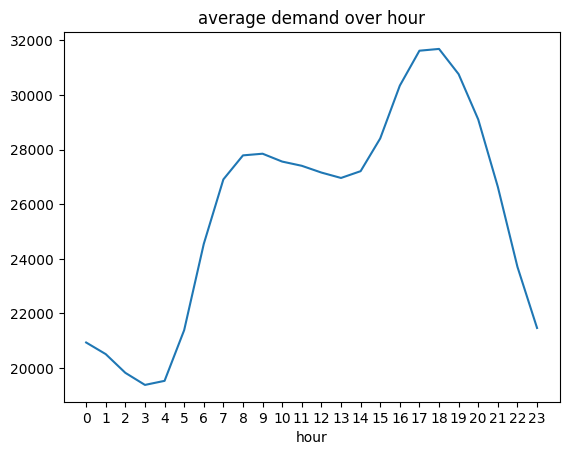

In [10]:
merge['hour']=merge['time'].dt.hour
merge.groupby('hour')['ENGLAND_WALES_DEMAND'].mean().plot()
plt.title('average demand over hour')
plt.xticks(range(24))
plt.show()

1.the peak of years gradually decreased years by years

2.seasonal fluctuating

3.daily fluctuating that the peak is in the afternoon at around 5-6pm,bottom is in the morning at about 3-4am

In [11]:
merge['dayofweek']=merge['time'].dt.dayofweek
merge['is_weekend']=merge['dayofweek']>5
print(merge.groupby('is_weekend')['ENGLAND_WALES_DEMAND'].mean())

is_weekend
False    25765.184945
True     25859.824673
Name: ENGLAND_WALES_DEMAND, dtype: float64


There is no difference between weekend demand and weekdays demand

In [12]:
import numpy as np

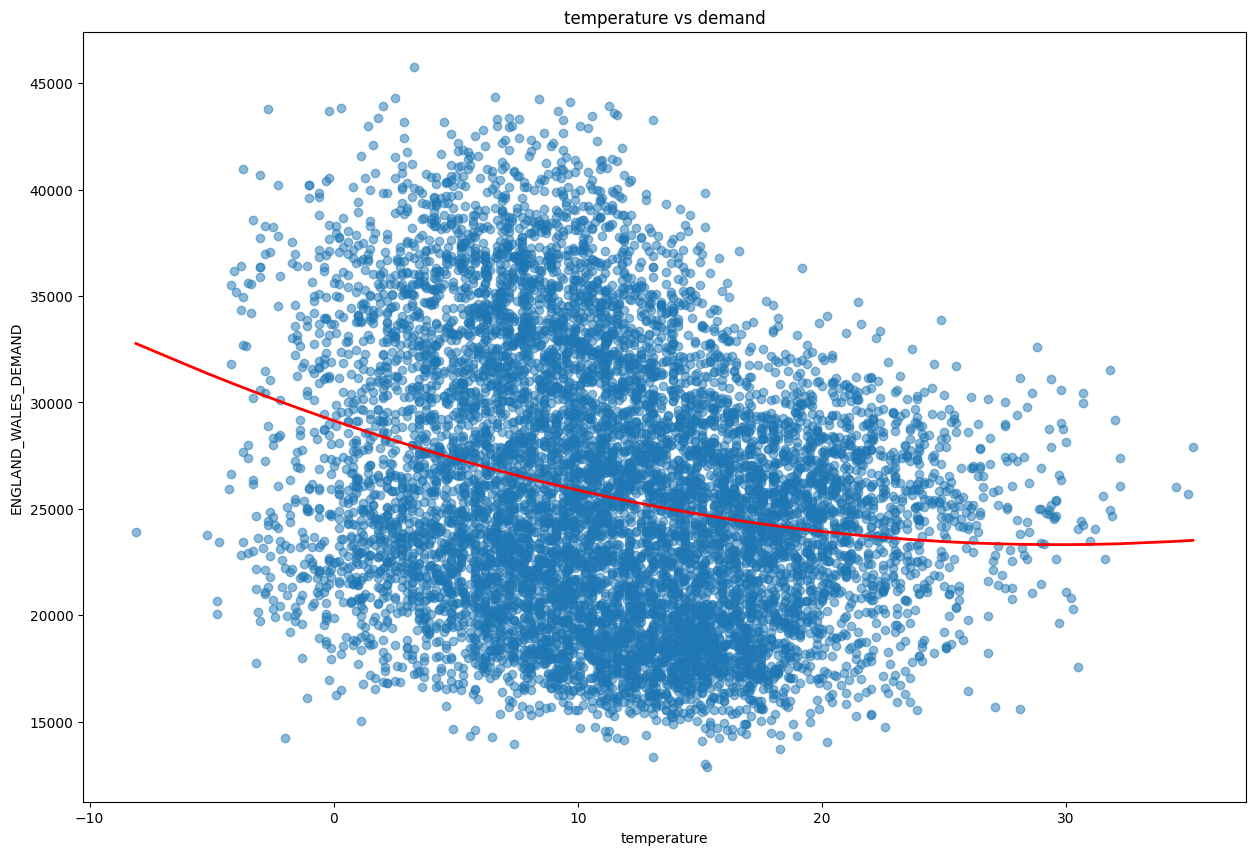

In [13]:
sample_merge=merge.sample(n=10000,random_state=77)
plt.figure(figsize=(15,10))
plt.scatter(sample_merge['temperature_2m'],sample_merge['ENGLAND_WALES_DEMAND'],alpha=0.5)
z=np.polyfit(sample_merge['temperature_2m'],sample_merge['ENGLAND_WALES_DEMAND'],2)
p=np.poly1d(z)
plt.plot(np.sort(sample_merge['temperature_2m']),p(np.sort(sample_merge['temperature_2m'])),linewidth=2,color='r')
plt.title('temperature vs demand')
plt.xlabel('temperature')
plt.ylabel('ENGLAND_WALES_DEMAND')
plt.show()

The temperature and demand is non-linear relation.Therefore,using polynomial to fit.

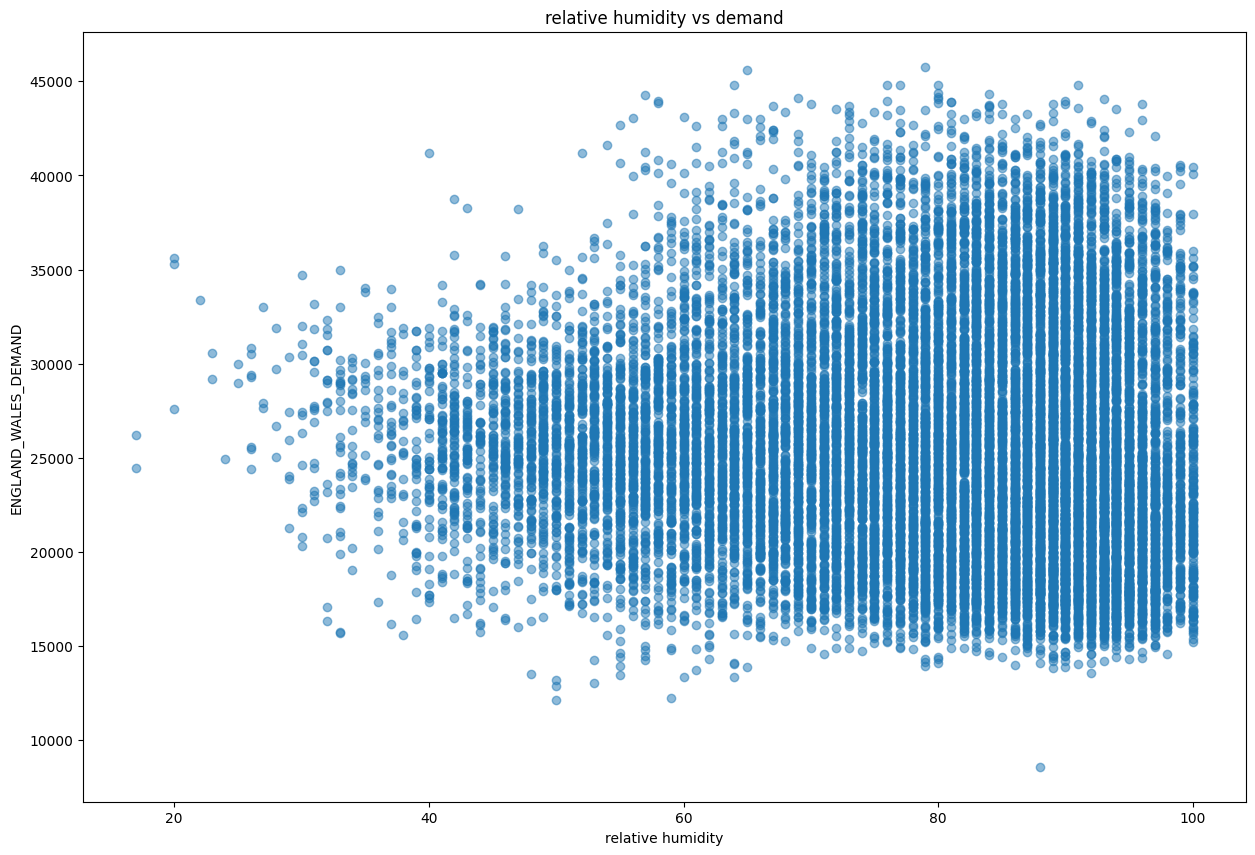

In [14]:
sample_merge=merge.sample(n=20000,random_state=77)
plt.figure(figsize=(15,10))
plt.scatter(sample_merge['relative_humidity_2m'],sample_merge['ENGLAND_WALES_DEMAND'],alpha=0.5)
plt.title('relative humidity vs demand')
plt.xlabel('relative humidity')
plt.ylabel('ENGLAND_WALES_DEMAND')
plt.show()

There is no relation between humidity and demand.

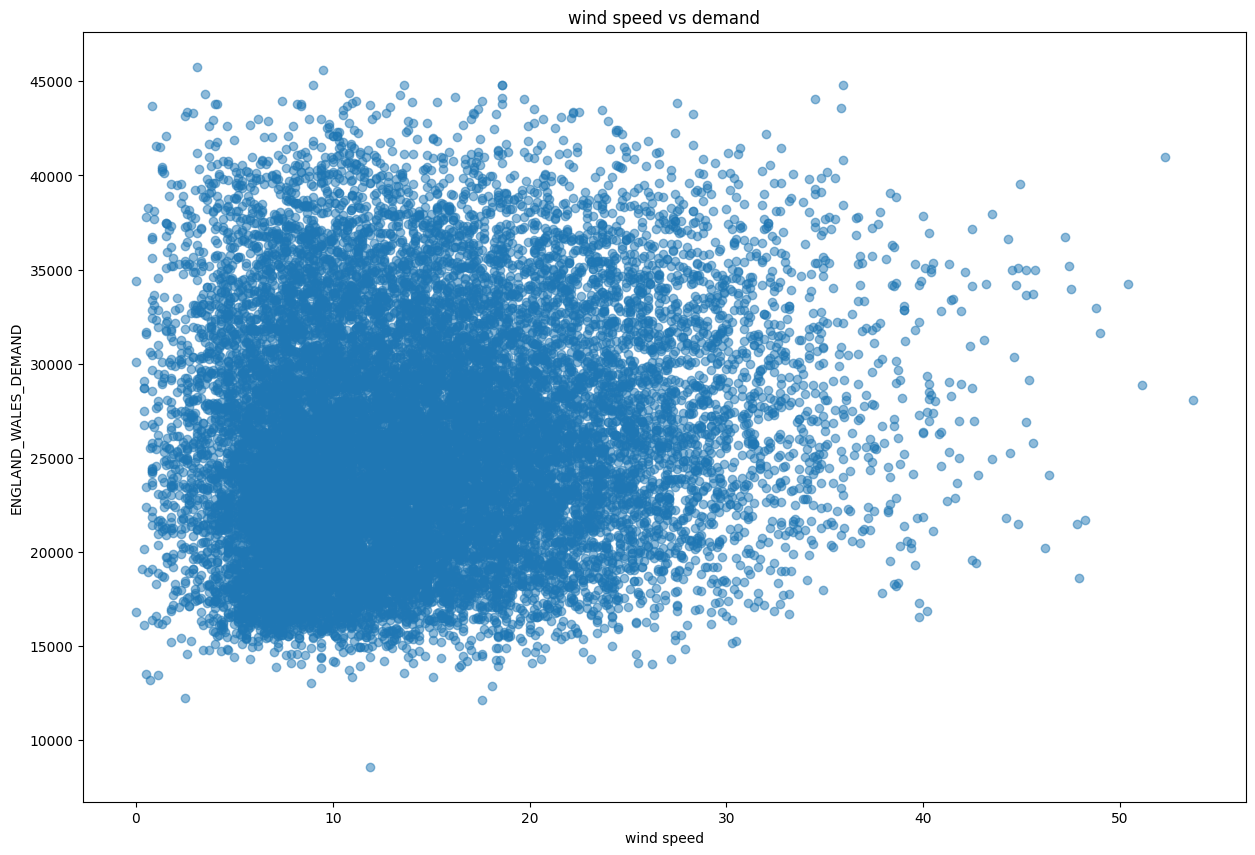

In [15]:
sample_merge=merge.sample(n=20000,random_state=77)
plt.figure(figsize=(15,10))
plt.scatter(sample_merge['wind_speed_10m'],sample_merge['ENGLAND_WALES_DEMAND'],alpha=0.5)
plt.title('wind speed vs demand')
plt.xlabel('wind speed')
plt.ylabel('ENGLAND_WALES_DEMAND')
plt.show()

There is no relation between wind speed and demand,other variables gonna be considered on supply model